# Replicate: MobileSAM 
### onnxruntime-gpu (.onnx)
conda activate MobileSAM_onnx
July 28th

In [ ]:
# New conda env

"""
# clean env wipe & activate
conda env remove --name mobilesam_py310 -y
conda create -n MobileSAM_onnx python=3.10 -y
conda activate MobileSAM_onnx

sudo apt update
sudo apt install libcudnn8 libcudnn8-dev
conda install -c conda-forge libstdcxx-ng=12 -y

# Instalation of MobileSAM repo requirements

pip install git+https://github.com/ChaoningZhang/MobileSAM.git

# pip install -r requirements.txt
# python setup.py install
pip install timm==1.0.17 ultralytics==8.0.120 matplotlib==3.5.3 'opencv-python<4.9' jetson-stats



# typical np version mismatch
pip uninstall -y numpy
pip install "numpy>=1.19.2,<2.0"
# pip install numpy==1.26.4 

# Now install the CUDA PyTorch 2.5.0a0 (compatible with jp61 torch)
pip install --no-cache https://developer.download.nvidia.com/compute/redist/jp/v61/pytorch/torch-2.5.0a0+872d972e41.nv24.08.17622132-cp310-cp310-linux_aarch64.whl

# download torchvision 0.20.0a0 (compatible with jp61 torch)
cd ~/vision/
python3 setup.py install
cd ~

# Install ONNX runtime (REPO INSTRUCTIONS: We recommend to use onnx==1.12.0 onnxruntime==1.13.1 which is tested)
pip install onnx==1.13.1 onnxruntime==1.13.1 

# copy over tensorrt
ls /usr/lib/python3.10/dist-packages/tensorrt/tensorrt.so
cp -r /usr/lib/python3.10/dist-packages/tensorrt* $CONDA_PREFIX/lib/python3.10/site-packages
python -c "import tensorrt; print(tensorrt.__version__)"

"""

# Debug Support

# Check your conda env GLIBCXX versions
# strings /home/copter/miniconda3/envs/nanosam_arm64/lib/python3.10/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6 | grep GLIBCXX

# trt2torch is apparently an issue and is obsolete for trt --version=10.3.0 
# additionally `pip install pycuda`

In [1]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from mobile_sam import sam_model_registry, SamPredictor
from mobile_sam.utils.onnx import SamOnnxModel

/home/copter/.local/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/copter/.local/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/copter/miniconda3/envs/MobileSAM_onnx/lib/python3.10/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/home/copter/miniconda3/envs/MobileSAM_onnx/lib/python3.10/site-pac

In [2]:
# ONNX MobileSAM Inference Setup
import os
import sys
import onnxruntime as ort
from typing import List, Tuple, Any
import time
import tensorrt

# Add FastSAM utils if needed for compatibility
sys.path.append('/home/copter/MobileSAM')

# Update library path to ensure cuDNN is found
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/aarch64-linux-gnu:' + os.environ.get('LD_LIBRARY_PATH', '')

In [3]:
# Verify versions

print(f"NumPy version: {np.__version__}")       # shold be 1.26.4 or else causes mem core dump issues
print("CUDA is available:", torch.cuda.is_available())
print(f"TensorRT version: {tensorrt.__version__}")
print("Available ONNX Runtime providers: ", ort.get_available_providers())

NumPy version: 1.26.4
TensorRT version: 10.3.0
Available ONNX Runtime providers:  ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [4]:
# 🧹 Clear the PyTorch CUDA cache
torch.cuda.empty_cache()

import gc
gc.collect()

16

In [5]:
def show_mask(mask, ax):
    color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))   

In [ ]:
# --- LOAD EXAMPLE DOG IMAGE ------------------------ #

# Load and display image
image_path = "/home/copter/jetson_benchmark/images/dogs.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
w, h = 1024, 1024

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis('on')
plt.title("Dogs Image")
plt.show()

print(f"Image size: {image.size}")

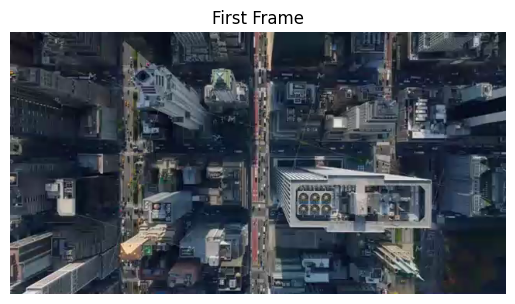

Original Image Shape: (338, 640, 3)


In [15]:
# --- LOAD VIDEO FRAME EXAMPLE ------------------------ #

# Create capture object -------------------------------- #

# video path (use for frame processing)
video_path = "/home/copter/Data/Aerial view of manhattan.mp4"

# Create a VideoCapture object
cap = cv2.VideoCapture(video_path)

# Check if video was opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

# Get video properties (frame width, height, and FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Define the codec and create a VideoWriter object to save the output
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # You can change the codec
out = cv2.VideoWriter('/home/copter/Data/output_nyc_video.mp4', fourcc, fps, (frame_width, frame_height))


# Read the first frame -------------------------------- #

ret, frame = cap.read()     # frame is a cv2 object in BGR format,

# Check if frame was read successfully
if ret:
    # Convert the frame to a PIL Image
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))       # img is a PIL object
    
    # # Resize the image and run the encoder
    # img = img.resize((1024, 1024), resample=Image.BILINEAR)
    # img_arr = np.array(img).astype(np.float32) / 255.0                  # this is a nd.array
    # input_image = img_arr.transpose(2, 0, 1)[None, :, :, :]
    
    # Display the first frame
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis('off')
    plt.show()

# Release the video objects
cap.release()

# Print image shape
print(f"Original Image Shape: {frame.shape}")  # (height, width, channels)
original_image = frame
image = original_image

This will be needed to both export the model and to calculate embeddings for the model.

In [16]:
# PT model configuration

checkpoint = "/home/copter/weights/chaoningzhang_mobile_sam.pt" # Adjust this path
model_type = "vit_t" # Or "vit_h", "vit_l" if using full SAM

# Instantiate the PyTorch SAM model
sam = sam_model_registry[model_type](checkpoint=checkpoint)
# sam.to(device='cpu') # Or 'cuda' if you have a GPU

In [17]:
# ONNX model configuration

onnx_model_path = "/home/copter/onnx_models/chaoningzhang_mobile_sam.onnx"
ort_session = ort.InferenceSession(onnx_model_path)

# Determine device availability
if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA device: {torch.cuda.get_device_name(0)} !!")
else:
    device = "cpu"
    print("Using CPU device.")

# To use the ONNX model, the image must first be pre-processed using the 
# SAM image encoder. This is a heavier weight process best performed on GPU. 
# SamPredictor can be used as normal, then .get_image_embedding() will retreive the intermediate features.

# Set device for SAM
sam.to(device=device)
predictor = SamPredictor(sam)

predictor.set_image(image)
image_embedding = predictor.get_image_embedding().cpu().numpy()
image_embedding.shape


2025-08-15 12:52:40.876700778 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1021503, index: 0, mask: {10, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-15 12:52:40.876770601 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1021504, index: 1, mask: {9, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-08-15 12:52:40.876827528 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 1021505, index: 2, mask: {8, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.


Using CUDA device: Orin !!


(1, 256, 64, 64)

### Example point input



The ONNX model has a different input signature than SamPredictor.predict. The following inputs must all be supplied. 

Note the special cases for both point and mask inputs. All inputs are np.float32.

`image_embeddings`: The image embedding from predictor.get_image_embedding(). Has a batch index of length 1.

`point_coords`: Coordinates of sparse input prompts, corresponding to both point inputs and box inputs. Boxes are encoded using two points, one for the top-left corner and one for the bottom-right corner. Coordinates must already be transformed to long-side 1024. Has a batch index of length 1.

`point_labels`: Labels for the sparse input prompts. 0 is a negative input point, 1 is a positive input point, 2 is a top-left box corner, 3 is a bottom-right box corner, and -1 is a padding point. If there is no box input, a single padding point with label -1 and coordinates (0.0, 0.0) should be concatenated.

`mask_input`: A mask input to the model with shape 1x1x256x256. This must be supplied even if there is no mask input. In this case, it can just be zeros.

`has_mask_input`: An indicator for the mask input. 1 indicates a mask input, 0 indicates no mask input.

`orig_im_size`: The size of the input image in (H,W) format, before any transformation.

Additionally, the ONNX model does not threshold the output mask logits. To obtain a binary mask, threshold at sam.mask_threshold (equal to 0.0).


In [27]:
# Prepare input data that remains constant across runs

p_x = int(frame.shape[1]/3) # width coordinate (x)
p_y = int(frame.shape[0]/3) # height coordinate (y)
print('dummy point (x, y): ', p_x, ',', p_y)

# Create point in [x, y] format as SAM expects
input_point = np.array([[p_x, p_y]])  # Note: [x, y] not [y, x]
input_label = np.array([1])

# Add a batch index, concatenate a padding point, and transform.
onnx_coord = np.concatenate([input_point, np.array([[0.0, 0.0]])], axis=0)[None, :, :]
onnx_label = np.concatenate([input_label, np.array([-1])], axis=0)[None, :].astype(np.float32)

onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)

# Create an empty mask input and an indicator for no mask.
onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
onnx_has_mask_input = np.zeros(1, dtype=np.float32)

# Define the ONNX inputs dictionary outside the loop as they are constant
ort_inputs_fixed = {
    "image_embeddings": image_embedding,
    "point_coords": onnx_coord,
    "point_labels": onnx_label,
    "mask_input": onnx_mask_input,
    "has_mask_input": onnx_has_mask_input,
    "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
}



dummy point (x, y):  213 , 112


Best mask index: 2, IoU score: 0.761
Original image dimensions: 640 x 338


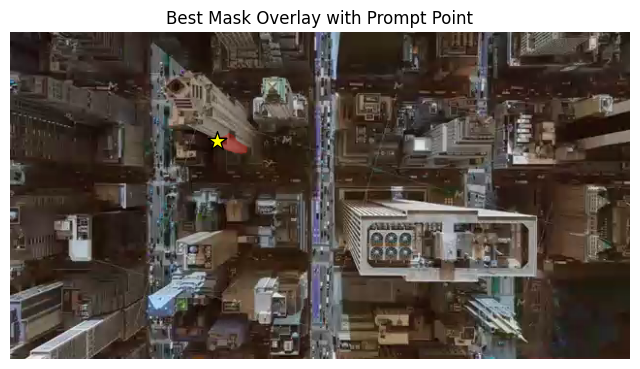

In [28]:
# ---- Image Demo ------------------------ #

masks, iou_predictions, low_res_logits = ort_session.run(None, ort_inputs_fixed)
point_coords = ort_inputs_fixed["point_coords"]

# 1) Pick the best mask based on the highest IoU score
scores_flat = iou_predictions.flatten()
best_idx = int(np.argmax(scores_flat))
print(f"Best mask index: {best_idx}, IoU score: {scores_flat[best_idx]:.3f}")

# 2) Extract and resize the best mask to the original image dimensions
raw_mask = masks[0, best_idx]
binary_mask = (raw_mask > 0.5).astype(np.uint8) * 255

# Get the actual image dimensions
img_height, img_width = image.shape[:2]
print(f"Original image dimensions: {img_width} x {img_height}")

mask_img = Image.fromarray(binary_mask)
resized_mask = mask_img.resize((img_width, img_height), Image.Resampling.BILINEAR)

# 3) Create a semi-transparent colored overlay from the resized mask
alpha_mask = resized_mask.point(lambda p: int(p * 0.3))  # 30% opacity
red_overlay = Image.new("RGBA", (img_width, img_height), (255, 0, 0, 0))
red_overlay.putalpha(alpha_mask)

# 4) Composite the overlay onto the original image
original_pil = Image.fromarray(image)  # Convert numpy array to PIL Image first
original_rgba = original_pil.convert("RGBA")
composited_image = Image.alpha_composite(original_rgba, red_overlay)

# 5) Display the result with the prompt point
star_x, star_y = p_x, p_y  # Use original coordinates
plt.figure(figsize=(8, 8))
plt.imshow(composited_image)
plt.scatter(star_x, star_y, marker="*", color="yellow", s=200, edgecolors="black")
plt.title("Best Mask Overlay with Prompt Point")
plt.axis("off")
plt.show()


### Grid-based Point Prompting (ONNX Compatible)

In [52]:
# Method 2: Grid-based Point Prompting (for ONNX model)
def everything_mode_grid_onnx(
        image, 
        ort_session, 
        predictor, 
        grid_size=16,
        iou_thresh=0.7,
        score_thresh=0.5
    ):
    """Generate masks using a grid of points with ONNX model"""
    
    img_height, img_width = image.shape[:2]
    
    # Create a grid of points
    x_points = np.linspace(img_width//grid_size, img_width-img_width//grid_size, grid_size)
    y_points = np.linspace(img_height//grid_size, img_height-img_height//grid_size, grid_size)
    
    all_masks = []
    all_points = []
    
    # Set image for predictor
    predictor.set_image(image)
    image_embedding = predictor.get_image_embedding().cpu().numpy()
    
    print(f"Processing {grid_size}x{grid_size} = {grid_size*grid_size} points...")
    
    for i, x in enumerate(x_points):
        for j, y in enumerate(y_points):
            # Create point input
            input_point = np.array([[int(x), int(y)]])
            input_label = np.array([1])
            
            # Prepare ONNX inputs
            onnx_coord = np.concatenate([input_point, np.array([[0.0, 0.0]])], axis=0)[None, :, :]
            onnx_label = np.concatenate([input_label, np.array([-1])], axis=0)[None, :].astype(np.float32)
            onnx_coord = predictor.transform.apply_coords(onnx_coord, image.shape[:2]).astype(np.float32)
            
            onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
            onnx_has_mask_input = np.zeros(1, dtype=np.float32)
            
            ort_inputs = {
                "image_embeddings": image_embedding,
                "point_coords": onnx_coord,
                "point_labels": onnx_label,
                "mask_input": onnx_mask_input,
                "has_mask_input": onnx_has_mask_input,
                "orig_im_size": np.array(image.shape[:2], dtype=np.float32)
            }
            
            # Run inference
            masks, iou_predictions, _ = ort_session.run(None, ort_inputs)
            
            # Get best mask
            best_idx = int(np.argmax(iou_predictions.flatten()))
            best_mask = masks[0, best_idx]
            best_iou = iou_predictions.flatten()[best_idx]
            
            # Only keep masks with good IoU scores
            if best_iou > iou_thresh:
                # Resize mask to original image size
                mask_img = Image.fromarray((best_mask > score_thresh).astype(np.uint8) * 255)
                resized_mask = mask_img.resize((img_width, img_height), Image.Resampling.BILINEAR)
                binary_mask = np.array(resized_mask) > 128
                
                # Filter by SIZE - ignore very small or very large masks
                area = np.sum(binary_mask)
                total_pixels = img_width * img_height
                area_ratio = area / total_pixels
                
                if 0.0005 < area_ratio < 0.15:  # Between 0.1% and 50% of image
                    all_masks.append({
                        'segmentation': binary_mask,
                        'area': area,
                        'point': (int(x), int(y)),
                        'iou': best_iou,
                        'area_ratio': area_ratio
                    })
                    all_points.append((int(x), int(y)))
    
    print(f"Generated {len(all_masks)} good quality masks")
    
    # Display results
    plt.figure(figsize=(20, 10))
    
    # Original with grid points
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    for point in all_points:
        plt.scatter(point[0], point[1], marker="*", color="yellow", s=50, edgecolors="black")
    plt.title(f"Grid Points ({len(all_points)} successful)")
    plt.axis('off')
    
    # Individual masks
    plt.subplot(1, 3, 2)
    plt.imshow(image)
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_masks)))
    for i, mask_info in enumerate(all_masks):
        mask = mask_info['segmentation']
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 4))
        colored_mask[mask, :3] = colors[i][:3]
        colored_mask[mask, 3] = 0.6
        plt.imshow(colored_mask)
    plt.title("All Generated Masks")
    plt.axis('off')
    
    # Sorted by area
    plt.subplot(1, 3, 3)
    plt.imshow(image)
    sorted_masks = sorted(all_masks, key=lambda x: x['area'], reverse=True)
    for i, mask_info in enumerate(sorted_masks[:10]):  # Show top 10 by area
        mask = mask_info['segmentation']
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 4))
        colored_mask[mask, :3] = colors[i % len(colors)][:3]
        colored_mask[mask, 3] = 0.6
        plt.imshow(colored_mask)
    plt.title("Top 10 Masks by Area")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return all_masks

Processing 10x10 = 100 points...
Generated 57 good quality masks


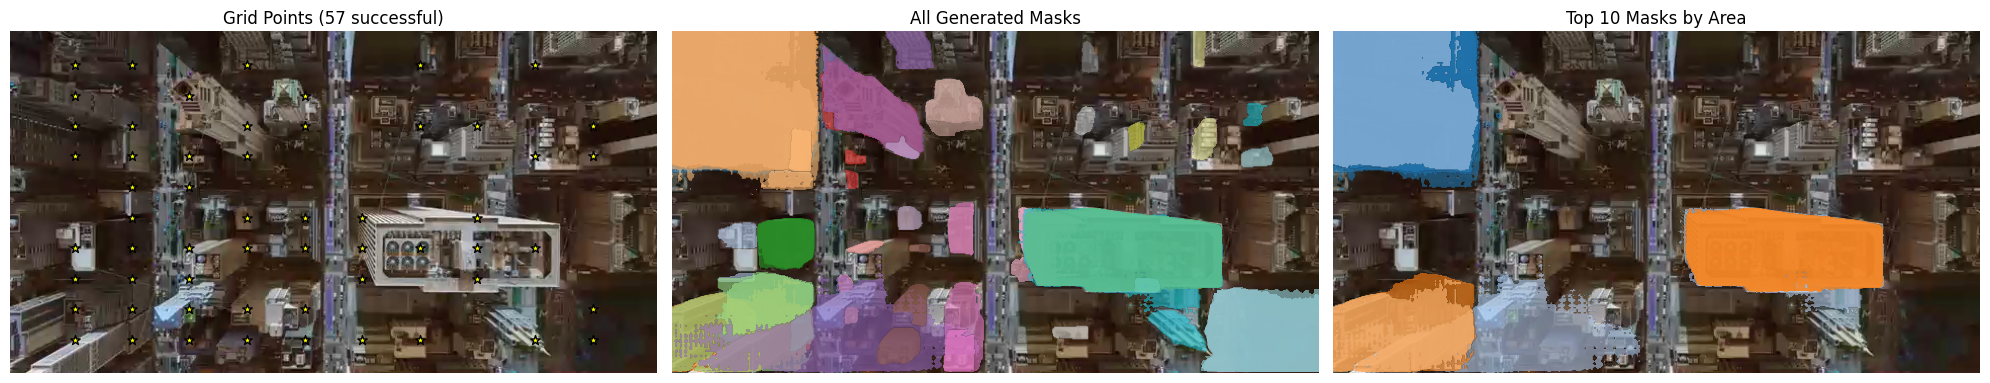

In [53]:
masks = everything_mode_grid_onnx(
    image, 
    ort_session, 
    predictor, 
    grid_size=10,
    iou_thresh=0.6,
    score_thresh=0.50
)

In [54]:
import matplotlib.patches as patches

def mask_to_bbox(mask):
    """Convert a binary mask to a bounding box [x, y, width, height]"""
    # Find all non-zero points
    coords = np.column_stack(np.where(mask))
    
    if len(coords) == 0:
        return None
    
    # Get min/max coordinates (note: coords are in [y, x] format from np.where)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # Convert to [x, y, width, height] format
    x = x_min
    y = y_min
    width = x_max - x_min + 1
    height = y_max - y_min + 1
    
    return [x, y, width, height]

# Alternative function to just add bboxes to existing results
def add_bbox_visualization(image, masks, title_prefix=""):
    """Add bounding box visualization to existing mask results"""
    
    # Convert masks to bboxes
    bboxes = []
    for mask_info in masks:
        bbox = mask_to_bbox(mask_info['segmentation'])
        if bbox is not None:
            bboxes.append({
                'bbox': bbox,
                'iou': mask_info['iou'],
                'area_ratio': mask_info.get('area_ratio', 0)
            })
    
    # Create the bbox overlay plot
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    
    ax = plt.gca()
    
    # Draw bounding boxes
    for i, bbox_info in enumerate(bboxes):
        x, y, width, height = bbox_info['bbox']
        
        # Create rectangle patch
        rect = patches.Rectangle(
            (x, y), width, height,
            linewidth=2,
            edgecolor='red',
            facecolor='none',
            alpha=0.8
        )
        ax.add_patch(rect)
        
        # Add IoU score as text
        plt.text(x, y-5, f"{bbox_info['iou']:.2f}", 
                color='red', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
    
    plt.title(f"{title_prefix}Overlaid Bboxes ({len(bboxes)} total)")
    plt.axis('off')
    plt.show()
    
    return bboxes

# Usage examples:
"""
# Method 1: Complete pipeline with bboxes
unique_masks, bboxes = everything_mode_grid_with_bboxes(image, ort_session, predictor, grid_size=10)

# Method 2: Add bboxes to existing results
bboxes = add_bbox_visualization(image, existing_masks, "Custom ")

# Access bbox coordinates for further processing:
for bbox_info in bboxes:
    x, y, width, height = bbox_info['bbox']
    confidence = bbox_info['iou']
    print(f"Object at ({x}, {y}) with size {width}x{height}, confidence: {confidence:.3f}")
"""

'\n# Method 1: Complete pipeline with bboxes\nunique_masks, bboxes = everything_mode_grid_with_bboxes(image, ort_session, predictor, grid_size=10)\n\n# Method 2: Add bboxes to existing results\nbboxes = add_bbox_visualization(image, existing_masks, "Custom ")\n\n# Access bbox coordinates for further processing:\nfor bbox_info in bboxes:\n    x, y, width, height = bbox_info[\'bbox\']\n    confidence = bbox_info[\'iou\']\n    print(f"Object at ({x}, {y}) with size {width}x{height}, confidence: {confidence:.3f}")\n'

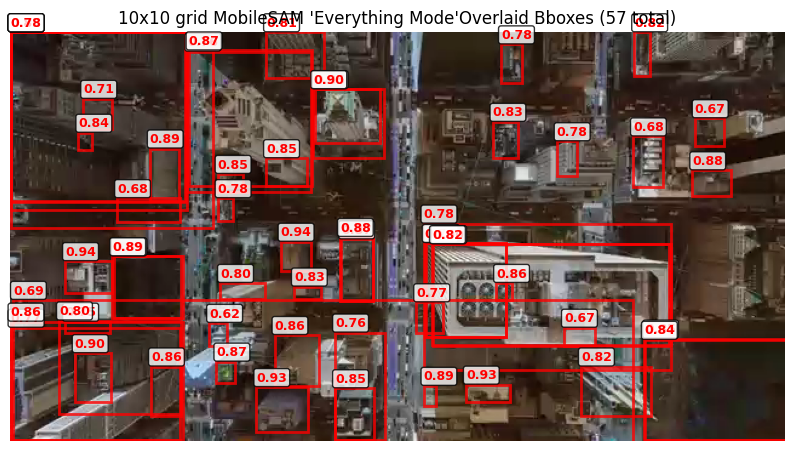

Object at (0, 0) with size 146x147, confidence: 0.932
Object at (60, 55) with size 24x25, confidence: 0.711
Object at (56, 83) with size 11x14, confidence: 0.840
Object at (0, 0) with size 144x139, confidence: 0.808
Object at (45, 189) with size 39x26, confidence: 0.939
Object at (45, 239) with size 37x9, confidence: 0.752
Object at (53, 265) with size 30x40, confidence: 0.895
Object at (0, 244) with size 140x93, confidence: 0.772
Object at (0, 0) with size 145x140, confidence: 0.851
Object at (0, 0) with size 167x162, confidence: 0.776
Object at (115, 96) with size 24x43, confidence: 0.892
Object at (88, 137) with size 52x20, confidence: 0.679
Object at (85, 185) with size 57x51, confidence: 0.890
Object at (84, 185) with size 57x51, confidence: 0.886
Object at (40, 238) with size 101x77, confidence: 0.796
Object at (0, 239) with size 142x98, confidence: 0.857
Object at (116, 276) with size 25x41, confidence: 0.864
Object at (146, 16) with size 102x116, confidence: 0.759
Object at (17

In [55]:
# Method 2: Add bboxes to existing results
bboxes = add_bbox_visualization(image, masks, "10x10 grid MobileSAM 'Everything Mode'")

# Access bbox coordinates for further processing:
for bbox_info in bboxes:
    x, y, width, height = bbox_info['bbox']
    confidence = bbox_info['iou']
    print(f"Object at ({x}, {y}) with size {width}x{height}, confidence: {confidence:.3f}")